In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [ ]:
n_feat_each_calc = []
feat_list_each_calc = []
complete_feat_list = []
feat_norm_freq = []
feat_abs_freq = []
out_path = '../../data/stat_sel_features/'
for i in range(1,129):
    path = out_path + str(i) +'/rfecv_features.txt'
    feat_list_each_calc += [pd.read_table(path, header=None, dtype=str)]
    n_feat_each_calc += [feat_list_each_calc[-1].size]
    for j in range(n_feat_each_calc[-1]):
        feature = feat_list_each_calc[-1].iloc[j,0]
        if not feature in complete_feat_list:
            complete_feat_list += [feature]
            feat_norm_freq += [1/n_feat_each_calc[-1]]
            feat_abs_freq += [1]
        else:
            indx = complete_feat_list.index(feature)
            feat_norm_freq[indx] += 1/n_feat_each_calc[-1]
            feat_abs_freq[indx] += 1

Text(0.5, 0, 'Feature index')

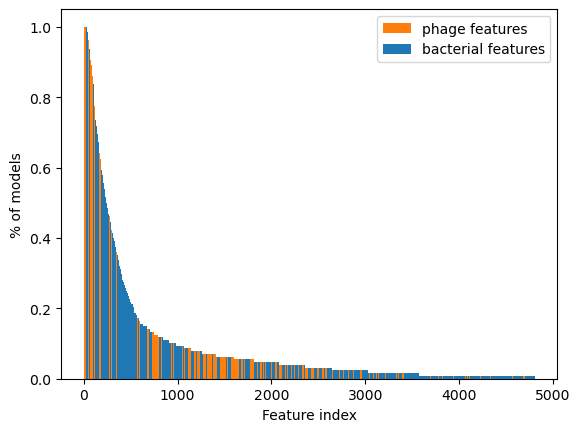

In [3]:
indices = np.flip(np.argsort(feat_abs_freq))
sorted_feat = np.array(complete_feat_list)[indices]
sorted_freq = np.array(feat_abs_freq)[indices]/128

cutoff = -1
freq = sorted_freq[sorted_freq > cutoff]
feat = sorted_feat[sorted_freq > cutoff]
n = (sorted_freq > cutoff).sum()

ph_index = np.array([f.endswith('_phage') for f in feat])

plt.bar(np.arange(1, n+1)[ph_index], freq[ph_index], width=1, color='C1', label='phage features')
plt.bar(np.arange(1, n+1)[~ph_index], freq[~ph_index], width=1, color='C0', label='bacterial features')

plt.legend()

# plt.bar(range(1, n+1), freq, width=1)
plt.ylabel('% of models')
plt.xlabel('Feature index')

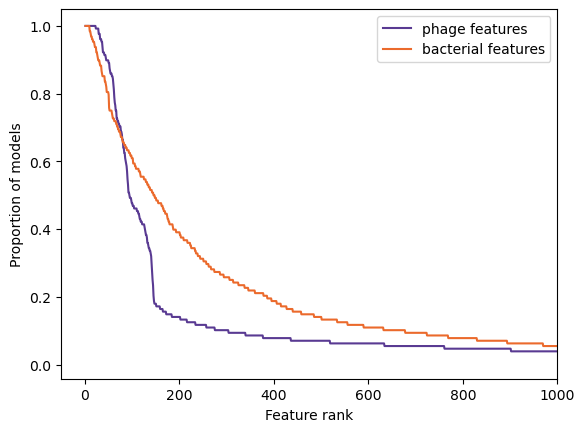

In [4]:
fig, ax = plt.subplots()
# plt.bar(np.arange(1, len(freq[ph_index])+1), freq[ph_index], width=1, color='C3', label='phage features', alpha=.5)
# plt.bar(np.arange(1, len(freq[~ph_index])+1), freq[~ph_index], width=1, color='C0', label='bacterial features', alpha=.5)
# ax.legend()
ax.set_xlabel('Feature rank')
ax.set_ylabel('Proportion of models')

ax.plot(np.arange(1, len(freq[ph_index])+1), freq[ph_index], color=(89/255, 58/255, 146/255), label='phage features')
ax.plot(np.arange(1, len(freq[~ph_index])+1), freq[~ph_index], color=(235/255, 106/255, 44/255), label='bacterial features')
ax.legend()
ax.set_xlim(-50, 1000)

path = '/Users/s2719230/Library/CloudStorage/OneDrive-UniversityofEdinburgh/Alison Low\'s files - Pan_Phage ML manuscript/figures/fig5.png'
# fig.savefig(path, dpi=300, bbox_inches='tight')